<a href="https://colab.research.google.com/github/melia1702/Pertemuan-ketigabelas/blob/main/PRAKTIKUM_13_2_MG_13.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


LATIHAN 2: SVM DENGAN BERBAGAI KERNEL
Dataset Shape: (300, 20)
Class Distribution: [100 100 100]


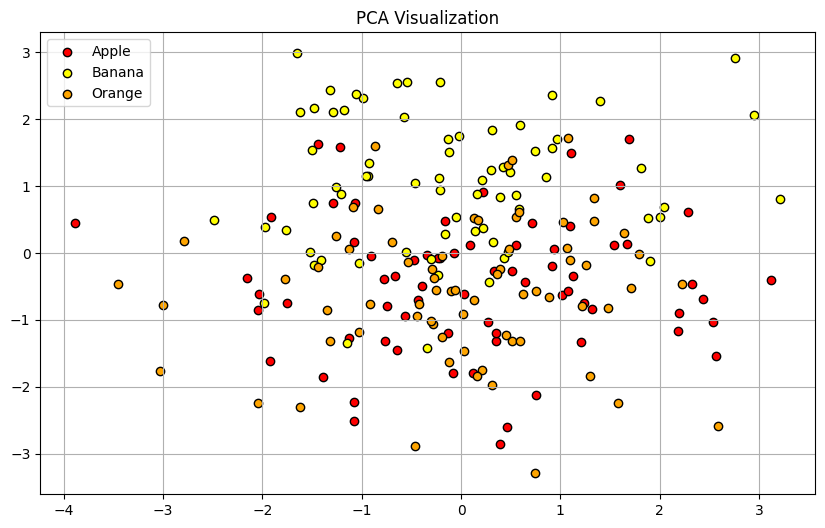

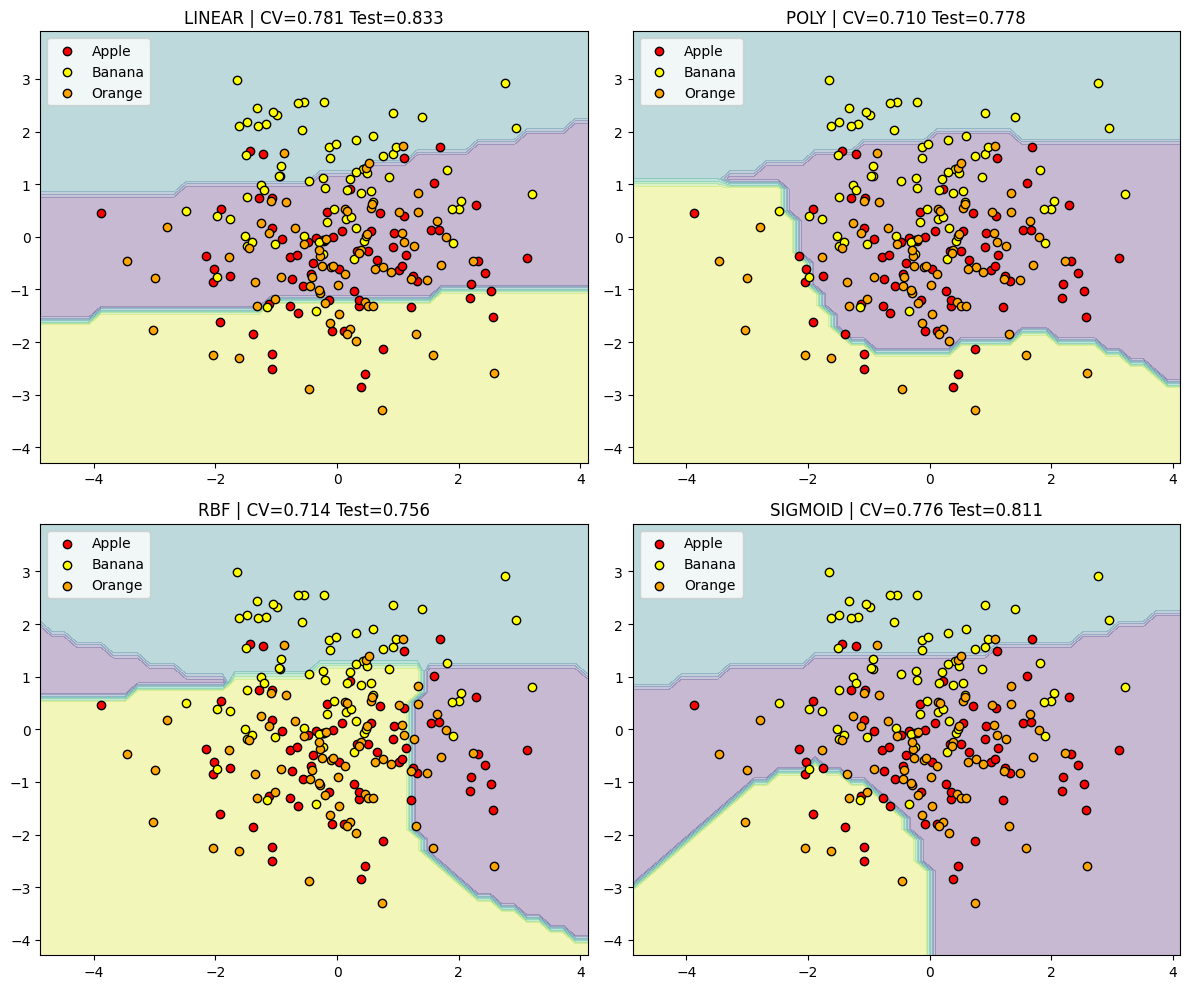


PERBANDINGAN:
linear: CV=0.7810, Test=0.8333
poly: CV=0.7095, Test=0.7778
rbf: CV=0.7143, Test=0.7556
sigmoid: CV=0.7762, Test=0.8111

Best Kernel: linear


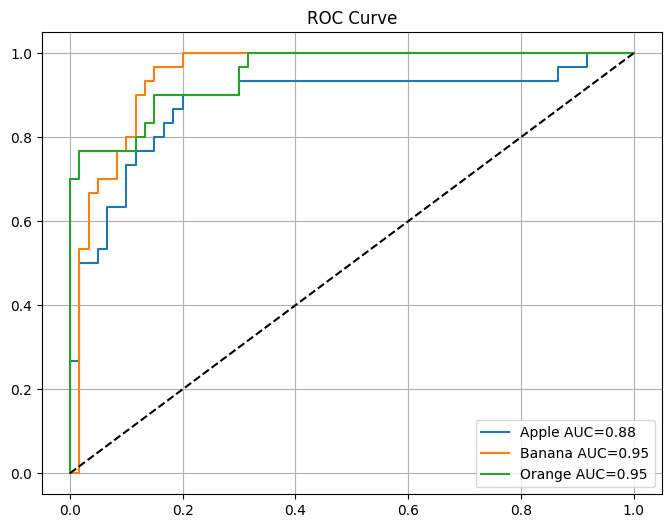

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.decomposition import PCA
from sklearn.metrics import roc_curve, auc
from sklearn.multiclass import OneVsRestClassifier
from sklearn import svm
import warnings
warnings.filterwarnings('ignore')

def praktikum_svm_fruits():
    print("\nLATIHAN 2: SVM DENGAN BERBAGAI KERNEL")
    print("=" * 50)

    # =========================
    # DATASET
    # =========================
    def create_fruit_dataset(n_samples=300):
        np.random.seed(42)
        n_features = 20

        apples = np.random.randn(n_samples, n_features)
        apples[:, 0] += 2
        apples[:, 1] += 1
        apples_labels = np.zeros(n_samples)

        bananas = np.random.randn(n_samples, n_features)
        bananas[:, 0] += 1
        bananas[:, 1] += 3
        bananas_labels = np.ones(n_samples)

        oranges = np.random.randn(n_samples, n_features)
        oranges[:, 0] += 1.5
        oranges[:, 1] += 1
        oranges[:, 2] += 2
        oranges_labels = np.ones(n_samples) * 2

        X = np.vstack([apples, bananas, oranges])
        y = np.hstack([apples_labels, bananas_labels, oranges_labels])

        return X, y

    X, y = create_fruit_dataset(100)
    fruit_names = ['Apple', 'Banana', 'Orange']

    print(f"Dataset Shape: {X.shape}")
    print(f"Class Distribution: {np.bincount(y.astype(int))}")

    # =========================
    # SPLIT + SCALING
    # =========================
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # =========================
    # PCA (UNTUK VISUALISASI)
    # =========================
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_train_scaled)

    plt.figure(figsize=(10, 6))
    colors = ['red', 'yellow', 'orange']

    for i, color in enumerate(colors):
        plt.scatter(X_pca[y_train == i, 0],
                    X_pca[y_train == i, 1],
                    c=color, label=fruit_names[i],
                    edgecolors='black')

    plt.title('PCA Visualization')
    plt.legend()
    plt.grid()
    plt.show()

    # =========================
    # SVM KERNEL
    # =========================
    kernels = ['linear', 'poly', 'rbf', 'sigmoid']
    results = {}

    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    axes = axes.ravel()

    for idx, kernel in enumerate(kernels):

        if kernel == 'poly':
            model = svm.SVC(kernel=kernel, degree=3, C=1.0, random_state=42)
        else:
            model = svm.SVC(kernel=kernel, C=1.0, random_state=42)

        # TRAIN
        model.fit(X_train_scaled, y_train)

        # EVALUASI
        acc = model.score(X_test_scaled, y_test)
        cv = cross_val_score(model, X_train_scaled, y_train, cv=5).mean()

        # =========================
        # DECISION BOUNDARY (FIX)
        # =========================
        x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
        y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1

        xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.2),
                             np.arange(y_min, y_max, 0.2))

        mesh = np.c_[xx.ravel(), yy.ravel()]

        # BALIKKAN KE DIMENSI ASLI
        mesh_original = pca.inverse_transform(mesh)
        mesh_scaled = scaler.transform(mesh_original)

        Z = model.predict(mesh_scaled)
        Z = Z.reshape(xx.shape)

        axes[idx].contourf(xx, yy, Z, alpha=0.3)

        for i, color in enumerate(colors):
            axes[idx].scatter(X_pca[y_train == i, 0],
                              X_pca[y_train == i, 1],
                              c=color, label=fruit_names[i],
                              edgecolors='black')

        axes[idx].set_title(f'{kernel.upper()} | CV={cv:.3f} Test={acc:.3f}')
        axes[idx].legend()

        results[kernel] = {'cv': cv, 'acc': acc, 'model': model}

    plt.tight_layout()
    plt.show()

    # =========================
    # HASIL
    # =========================
    print("\nPERBANDINGAN:")
    for k, v in results.items():
        print(f"{k}: CV={v['cv']:.4f}, Test={v['acc']:.4f}")

    # =========================
    # ROC CURVE
    # =========================
    best_kernel = max(results, key=lambda x: results[x]['acc'])
    print(f"\nBest Kernel: {best_kernel}")

    y_test_bin = label_binarize(y_test, classes=[0,1,2])

    ovr = OneVsRestClassifier(
        svm.SVC(kernel=best_kernel, probability=True)
    )

    ovr.fit(X_train_scaled, y_train)
    y_score = ovr.predict_proba(X_test_scaled)

    plt.figure(figsize=(8,6))

    for i in range(3):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'{fruit_names[i]} AUC={roc_auc:.2f}')

    plt.plot([0,1],[0,1],'k--')
    plt.legend()
    plt.title("ROC Curve")
    plt.grid()
    plt.show()

    return results

# RUN
svm_results = praktikum_svm_fruits()